# 2: xarray & the Data Cube

Build a **Sentinel-2 stack** (time × band × y × x) from Cloud-Optimized GeoTIFFs, then select by label, compute NDVI, and plot a time series.


## The data cube

A raster data cube is a labeled multi-dimensional array:

- **Spatial:** `y`, `x`
- **Temporal:** `time`
- **Thematic:** `band` (e.g. B04 red, B08 NIR)

xarray names those axes, so selection is `stack.sel(time=..., band="B04")` instead of `arr[0, 3, :, :]`.


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import rioxarray
import pystac_client
import planetary_computer
from rioxarray.exceptions import NoDataInBounds  # raised when CLIP misses a tile

## Search and sign

- `BBOX` / `CLIP` are `[min_lon, min_lat, max_lon, max_lat]` (west, south, east, north).
- `CLIP` is a small window so the stack stays workshop-sized.
- Planetary Computer URLs must be **signed** before opening.

In [9]:
# Northern Karnataka, India (same study area as Notebook 1)
BBOX = [75.62, 16.20, 77.29, 17.47]  # full study area
CLIP = (76.40, 16.75, 76.55, 16.90)  # small window: (west, south, east, north)
BANDS = ["B02", "B03", "B04", "B08"]  # blue, green, red, near-infrared

# Open the public STAC API (no key needed to search)
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1"
)

# Search tiles that overlap CLIP so every scene can be stacked
search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=list(CLIP),
    datetime="2023-01-01/2023-06-30",
    max_items=8,
    query={"eo:cloud_cover": {"lt": 15}},  # keep mostly cloud-free scenes
)

# Sign each item (required for Planetary Computer asset URLs), oldest first
items = sorted(
    (planetary_computer.sign(it) for it in search.items()),
    key=lambda it: it.datetime,
)

print(f"{len(items)} scenes")
for it in items:
    cc = it.properties.get("eo:cloud_cover")
    print(it.datetime.date(), f"cloud={cc:.1f}%" if cc is not None else "")

8 scenes
2023-05-01 cloud=5.5%
2023-05-16 cloud=0.0%
2023-05-21 cloud=0.4%
2023-05-26 cloud=0.0%
2023-05-26 cloud=0.0%
2023-06-05 cloud=12.3%
2023-06-05 cloud=12.3%
2023-06-20 cloud=0.1%


## Stack COGs into an xarray Dataset

For each STAC item:

1. Open B02/B03/B04/B08 as xarray (still in the cloud).
2. Clip to `CLIP` so only that window is read.
3. Align later scenes to the first scene (`reproject_match`) so pixels line up.
4. Stack with `xr.concat(..., dim="time")`.

Adjacent Sentinel-2 tiles can share the same datetime. Those duplicates are averaged so `.sel(time=...)` works.

In [10]:
def open_scene(item, bands, clip):
    """One STAC item → Dataset of clipped bands, with a time coordinate."""
    arrays = {}
    for band in bands:
        # Open the COG URL. masked=True turns nodata into NaN.
        da = rioxarray.open_rasterio(item.assets[band].href, masked=True)
        # Single-band files still have a dummy "band" dim of length 1 — drop it.
        da = da.squeeze("band", drop=True)
        # Read only the CLIP rectangle (lon/lat). Other pixels are not downloaded.
        da = da.rio.clip_box(
            minx=clip[0], miny=clip[1], maxx=clip[2], maxy=clip[3], crs="EPSG:4326"
        )
        arrays[band] = da

    ds = xr.Dataset(arrays)

    # xarray time coords work best as timezone-naive pandas timestamps
    t = pd.Timestamp(item.datetime)
    if t.tzinfo is not None:
        t = t.tz_convert("UTC").tz_localize(None)
    return ds.expand_dims(time=[t])


scenes = []
for it in items:
    try:
        scenes.append(open_scene(it, BANDS, CLIP))
    except NoDataInBounds:
        print("skip (CLIP does not overlap this tile):", it.id)

if not scenes:
    raise RuntimeError("No scenes overlapped CLIP. Change CLIP or the search bbox.")

# Warp every later scene onto the first scene's grid (same CRS, pixel size, extent)
reference = scenes[0]
aligned = [reference] + [s.rio.reproject_match(reference) for s in scenes[1:]]

# Stack along time, then merge tiles that share the same timestamp
stack = xr.concat(aligned, dim="time").sortby("time")
stack = stack.groupby("time").mean(keep_attrs=True)
stack = stack.rio.write_crs(reference.rio.crs)
stack

<xarray.Dataset> Size: 259MB
Dimensions:      (time: 6, y: 1673, x: 1612)
Coordinates:
  * time         (time) datetime64[ns] 48B 2023-05-01T05:16:49.024000 ... 202...
  * y            (y) float64 13kB 1.869e+06 1.869e+06 ... 1.852e+06 1.852e+06
  * x            (x) float64 13kB 6.491e+05 6.491e+05 ... 6.652e+05 6.652e+05
    spatial_ref  int64 8B 0
Data variables:
    B02          (time, y, x) float32 65MB 1.618e+03 1.554e+03 ... 1.606e+03
    B03          (time, y, x) float32 65MB 1.722e+03 1.588e+03 ... 1.774e+03
    B04          (time, y, x) float32 65MB 1.874e+03 1.702e+03 ... 2.002e+03
    B08          (time, y, x) float32 65MB 2.252e+03 2.082e+03 ... 2.422e+03

## Inspect the cube

A **Dataset** holds several DataArrays (`B02`, `B03`, …) that share `time`, `y`, `x`. `to_array("band")` is the 4-D view `(band, time, y, x)`.

In [11]:
# sizes = how many steps along each dimension
print("dims:", dict(stack.sizes))
# time labels should look like 2023-05-01, not a raw number
print("times:", [str(t)[:10] for t in stack["time"].values])
print("CRS:", stack.rio.crs)
print()

# Dataset (B02, B03, ...) → one DataArray with an extra "band" dimension
cube = stack.to_array(dim="band")
print("4-D cube dims:", cube.dims, "shape:", cube.shape)
cube

dims: {'time': 6, 'y': 1673, 'x': 1612}
times: ['2023-05-01', '2023-05-16', '2023-05-21', '2023-05-26', '2023-06-05', '2023-06-20']
CRS: EPSG:32643

4-D cube dims: ('band', 'time', 'y', 'x') shape: (4, 6, 1673, 1612)


<xarray.DataArray (band: 4, time: 6, y: 1673, x: 1612)> Size: 259MB
array([[[[1618. , 1554. , 1528. , ..., 1535. , 1564. , 1570. ],
         [1664. , 1584. , 1554. , ..., 1538. , 1562. , 1562. ],
         [1686. , 1604. , 1581. , ..., 1544. , 1562. , 1571. ],
         ...,
         [1590. , 1582. , 1600. , ..., 1520. , 1524. , 1517. ],
         [1647. , 1654. , 1718. , ..., 1518. , 1520. , 1512. ],
         [1684. , 1724. , 1802. , ..., 1495. , 1502. , 1515. ]],

        [[1652. , 1505. , 1470. , ..., 1439. , 1474. , 1482. ],
         [1695. , 1572. , 1516. , ..., 1470. , 1450. , 1458. ],
         [1768. , 1630. , 1544. , ..., 1472. , 1482. , 1499. ],
         ...,
         [1629. , 1580. , 1644. , ..., 1512. , 1498. , 1474. ],
         [1730. , 1702. , 1881. , ..., 1488. , 1472. , 1448. ],
         [1784. , 1830. , 1886. , ..., 1498. , 1492. , 1473. ]],

        [[1742. , 1552. , 1522. , ..., 1482. , 1478. , 1514. ],
         [1838. , 1622. , 1578. , ..., 1471. , 1449. , 1462. ],
         [1886. , 1708. , 1618. , ..., 1466. , 1460. , 1510. ],
         ...,
...
         [2676. , 2718. , 2841. , ..., 2395. , 2396. , 2390. ],
         [2702. , 2869. , 3067. , ..., 2393. , 2385. , 2393. ],
         [2734. , 2911. , 3077. , ..., 2398. , 2395. , 2401. ]],

        [[2233. , 2064. , 1990. , ..., 2979. , 3356. , 3233. ],
         [2262. , 2096. , 2019. , ..., 2932. , 3249. , 3266. ],
         [2278. , 2143. , 2098. , ..., 2871. , 3136. , 3207. ],
         ...,
         [2716. , 2639. , 2773. , ..., 2185. , 2177. , 2167. ],
         [2817. , 2834. , 2906. , ..., 2168. , 2172. , 2185. ],
         [2874. , 2992. , 3016. , ..., 2170. , 2173. , 2183. ]],

        [[2410. , 2218. , 2176. , ..., 3098. , 3472. , 3328. ],
         [2444. , 2262. , 2248. , ..., 3108. , 3466. , 3356. ],
         [2484. , 2322. , 2266. , ..., 3098. , 3314. , 3354. ],
         ...,
         [2810. , 2804. , 2844. , ..., 2462. , 2408. , 2422. ],
         [2936. , 2904. , 3024. , ..., 2464. , 2422. , 2420. ],
         [3008. , 3036. , 3082. , ..., 2470. , 2464. , 2422. ]]]],
      shape=(4, 6, 1673, 1612), dtype=float32)
Coordinates:
  * band         (band) object 32B 'B02' 'B03' 'B04' 'B08'
  * time         (time) datetime64[ns] 48B 2023-05-01T05:16:49.024000 ... 202...
  * y            (y) float64 13kB 1.869e+06 1.869e+06 ... 1.852e+06 1.852e+06
  * x            (x) float64 13kB 6.491e+05 6.491e+05 ... 6.652e+05 6.652e+05
    spatial_ref  int64 8B 0

## Select by label (`.sel`) and index (`.isel`)

- **`.isel`** — by position: `0` is the first date, `-1` is the last.
- **`.sel`** — by coordinate: a date string such as `"2023-05-01"`.
- `method="nearest"` picks the closest date if that exact day is not in the cube.

In [12]:
# By position: first and last date in the stack
first = stack.isel(time=0)
last = stack.isel(time=-1)

# By date label (year-month-day). "nearest" avoids a KeyError if the time is 10:16 UTC.
date0 = str(stack["time"].values[0])[:10]
red = stack["B04"].sel(time=date0, method="nearest")
nir = stack["B08"].sel(time=date0, method="nearest")

# First three dates (or fewer if the stack is shorter)
early = stack.isel(time=slice(0, min(3, stack.sizes["time"])))

print("First date:", date0)
print("B04 shape (rows, cols):", red.shape)
print("Early dates:", [str(t)[:10] for t in early["time"].values])
red

First date: 2023-05-01
B04 shape (rows, cols): (1673, 1612)
Early dates: ['2023-05-01', '2023-05-16', '2023-05-21']


<xarray.DataArray 'B04' (y: 1673, x: 1612)> Size: 11MB
array([[1874., 1702., 1670., ..., 1724., 1722., 1688.],
       [1968., 1782., 1717., ..., 1719., 1720., 1684.],
       [2022., 1838., 1760., ..., 1736., 1728., 1717.],
       ...,
       [1998., 1988., 2068., ..., 1730., 1728., 1722.],
       [2116., 2156., 2260., ..., 1716., 1722., 1722.],
       [2180., 2288., 2378., ..., 1722., 1711., 1715.]],
      shape=(1673, 1612), dtype=float32)
Coordinates:
  * y            (y) float64 13kB 1.869e+06 1.869e+06 ... 1.852e+06 1.852e+06
  * x            (x) float64 13kB 6.491e+05 6.491e+05 ... 6.652e+05 6.652e+05
    time         datetime64[ns] 8B 2023-05-01T05:16:49.024000
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

## RGB from the stack

One date, bands B04/B03/B02 (red, green, blue). Percentile stretch for display.

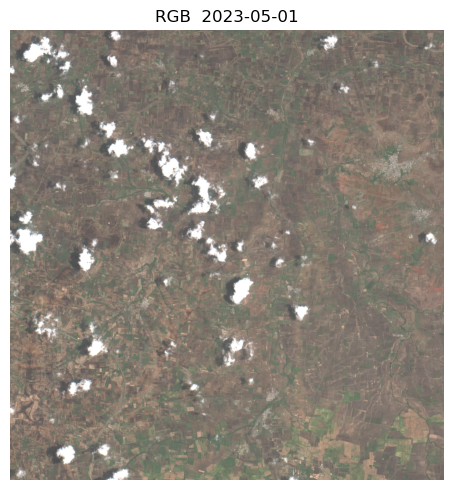

In [13]:
def rgb_image(ds):
    """Stack red, green, blue and stretch to 0–1 for matplotlib."""
    # Sentinel-2 band order for a true-color image: B04, B03, B02
    rgb = np.stack([ds["B04"].values, ds["B03"].values, ds["B02"].values])
    img = np.moveaxis(rgb, 0, -1).astype("float32")  # (rows, cols, 3)
    valid = img[np.isfinite(img) & (img > 0)]
    hi = np.percentile(valid, 98) if valid.size else 1  # ignore outliers
    return np.clip(img / hi, 0, 1)


date0 = str(stack.time.values[0])[:10]
img = rgb_image(stack.isel(time=0))

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(img)
ax.set_title(f"RGB  {date0}")
ax.axis("off")
plt.tight_layout()
plt.show()

## NDVI

NDVI = (NIR − red) / (NIR + red) = (B08 − B04) / (B08 + B04).

Sentinel-2 L2A is stored as scaled reflectance (`uint16`). The ratio is unchanged, so no scale factor is required.

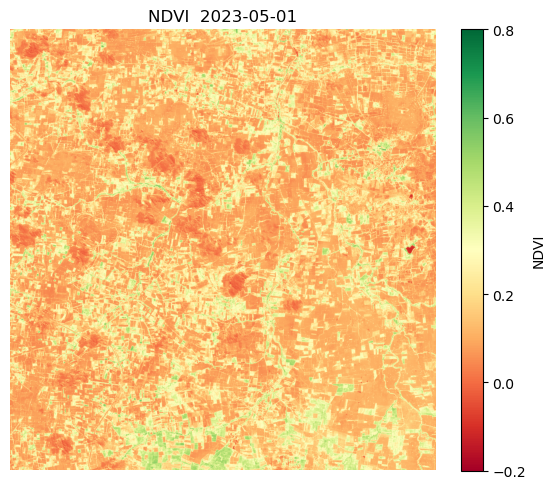

In [14]:
# NDVI is high for vegetation (~0.3–0.8) and low for soil/water
stack["ndvi"] = (stack["B08"] - stack["B04"]) / (stack["B08"] + stack["B04"])
ndvi0 = stack["ndvi"].isel(time=0)
date0 = str(stack.time.values[0])[:10]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(ndvi0, cmap="RdYlGn", vmin=-0.2, vmax=0.8)
ax.set_title(f"NDVI  {date0}")
ax.axis("off")
plt.colorbar(im, ax=ax, fraction=0.046, label="NDVI")
plt.tight_layout()
plt.show()

## NDVI time series

Mean NDVI over the window, one value per date. This is a spatial reduction: `mean(dim=["y", "x"])`.

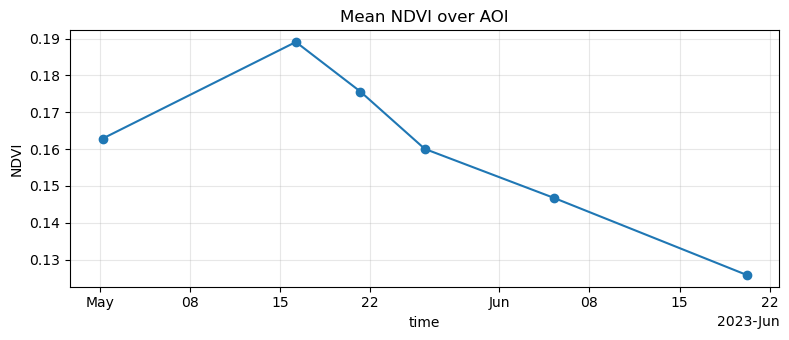

time
2023-05-01 05:16:49.024    0.163
2023-05-16 05:16:51.024    0.189
2023-05-21 05:16:59.024    0.176
2023-05-26 05:16:51.024    0.160
2023-06-05 05:16:51.024    0.147
2023-06-20 05:16:59.024    0.126
Name: ndvi, dtype: float32

In [15]:
# Collapse space: one NDVI number per date (the map average)
ts = stack["ndvi"].mean(dim=["y", "x"])

fig, ax = plt.subplots(figsize=(8, 3.5))
ts.plot(ax=ax, marker="o")
ax.set_ylabel("NDVI")
ax.set_title("Mean NDVI over AOI")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

ts.to_series().round(3)

## More cube operations

- **Time composite:** mean over `time` → one NDVI map
- **Threshold:** vegetation where NDVI > 0.3

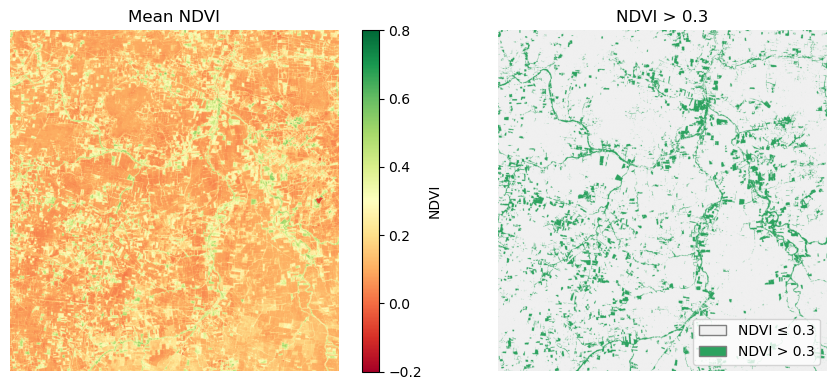

In [17]:
# Mean over time → one summary map
ndvi_mean = stack["ndvi"].mean(dim="time")
# Simple vegetation mask (1 = likely vegetation)
veg = xr.where(ndvi_mean > 0.3, 1, 0)

from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Continuous NDVI: colorbar is the legend; axis("off") hides x/y coordinates
im0 = axes[0].imshow(ndvi_mean, cmap="RdYlGn", vmin=-0.2, vmax=0.8)
axes[0].set_title("Mean NDVI")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, label="NDVI")

# Binary mask: two-class legend instead of a colorbar
cmap_veg = ListedColormap(["#f0f0f0", "#2ca25f"])
axes[1].imshow(veg, cmap=cmap_veg, vmin=0, vmax=1)
axes[1].set_title("NDVI > 0.3")
axes[1].axis("off")
axes[1].legend(
    handles=[
        Patch(facecolor="#f0f0f0", edgecolor="0.5", label="NDVI \u2264 0.3"),
        Patch(facecolor="#2ca25f", edgecolor="0.5", label="NDVI > 0.3"),
    ],
    loc="lower right",
)
plt.tight_layout()
plt.show()
